# Import Packages

In [2]:
# Load in packages
# -------------------------------------- #
from momus.hoggfit import hoggfit, analyze_hoggfit
import matplotlib.pyplot as plt
import numpy as np
# -------------------------------------- #

# Matplotlib Style 
# -------------------------------------- #
# fm.fontManager.__init__()
plt.style.use('seaborn-v0_8-deep')
plt.rcParams.update({
    "font.family": "Palatino",
    "mathtext.fontset": "stix",
    "mathtext.rm": "Palatino",
    'font.size': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'axes.linewidth': 1.2,
    'legend.fontsize': 11
})
# -------------------------------------- #

### Test Data

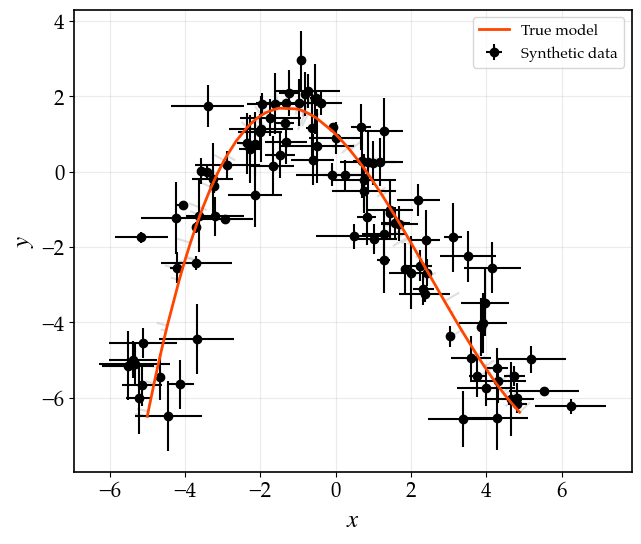

In [5]:
n_data = 100

a_true = 0.04
b_true = -0.3
c_true = -1
d_true = 1.0

V_true = 0.25
x_err_max = 1
y_err_max = 1

np.random.seed(1)

x = np.sort(np.random.uniform(-5, 5, n_data))
y_model = a_true*x**3 + b_true*x**2 + c_true*x + d_true

# measurement uncertainties
x_err = np.random.uniform(0.02, x_err_max, n_data)
y_err = np.random.uniform(0.02, y_err_max, n_data)
x_noise = np.random.normal(0, x_err)
y_noise = np.random.normal(0, y_err)

# intrinsic scatter
dy_dx = (3*a_true*x**2 + 2*b_true*x + c_true)
norm = np.sqrt(1+dy_dx**2)
nx = -dy_dx/norm
ny = 1/norm
V_offset = np.random.normal(0, V_true, n_data)

x_obs = x + x_noise + (V_offset*nx)
y_obs = y_model + y_noise + (V_offset*ny)

fig, ax = plt.subplots(figsize=(8,6))

ax.errorbar(x_obs, y_obs, xerr = x_err, yerr=y_err, fmt="o", color="black", label="Synthetic data")
ax.plot(x, y_model, color="orangered", lw=2, label="True model", zorder=10)

for i in range(n_data):
    x_temp = [float(x[i] + V_offset[i]*nx[i]), float(x[i])]
    y_temp = [float(y_model[i] + V_offset[i]*ny[i]), float(y_model[i])]
    ax.plot(x_temp, y_temp, color="gray", alpha=0.25, zorder=0)

ax.grid(alpha=0.25)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend()

ax.set_aspect('equal', adjustable='box')
plt.savefig("synthetic_data.pdf", bbox_inches="tight")

### Real Data (7-Order)

In [ ]:
import pandas as pd
df = pd.read_csv("/Users/hunter_brooks8/Documents/EOS/total_spec/EOS Sample - Platinum Sample.csv")
x_obs = df['sptnum_adp']
y_obs = df['Lbol']
Lbol_upper = np.abs(df['Lbol'] - df['Lbol_upper'])
Lbol_lower = np.abs(df['Lbol'] - df['Lbol_lower'])
y_err = 0.5*(Lbol_lower + Lbol_upper)

mask = np.isfinite(x_obs) & np.isfinite(y_obs) & np.isfinite(y_err)
x_obs = x_obs[mask]
y_obs = y_obs[mask]

x_err = [1]*len(y_err[mask])
y_err = y_err[mask]

plt.errorbar(x_obs, y_obs, xerr = x_err,yerr = y_err, fmt = 'o')

### Using Data

In [8]:
order = 3
sampler = hoggfit(x_obs, y_obs, xerr = x_err, yerr = y_err, order = order, nsteps=10000, nwalkers=30, ncores = 6)
# , ncores=1

100%|██████████| 10000/10000 [02:07<00:00, 78.14it/s]


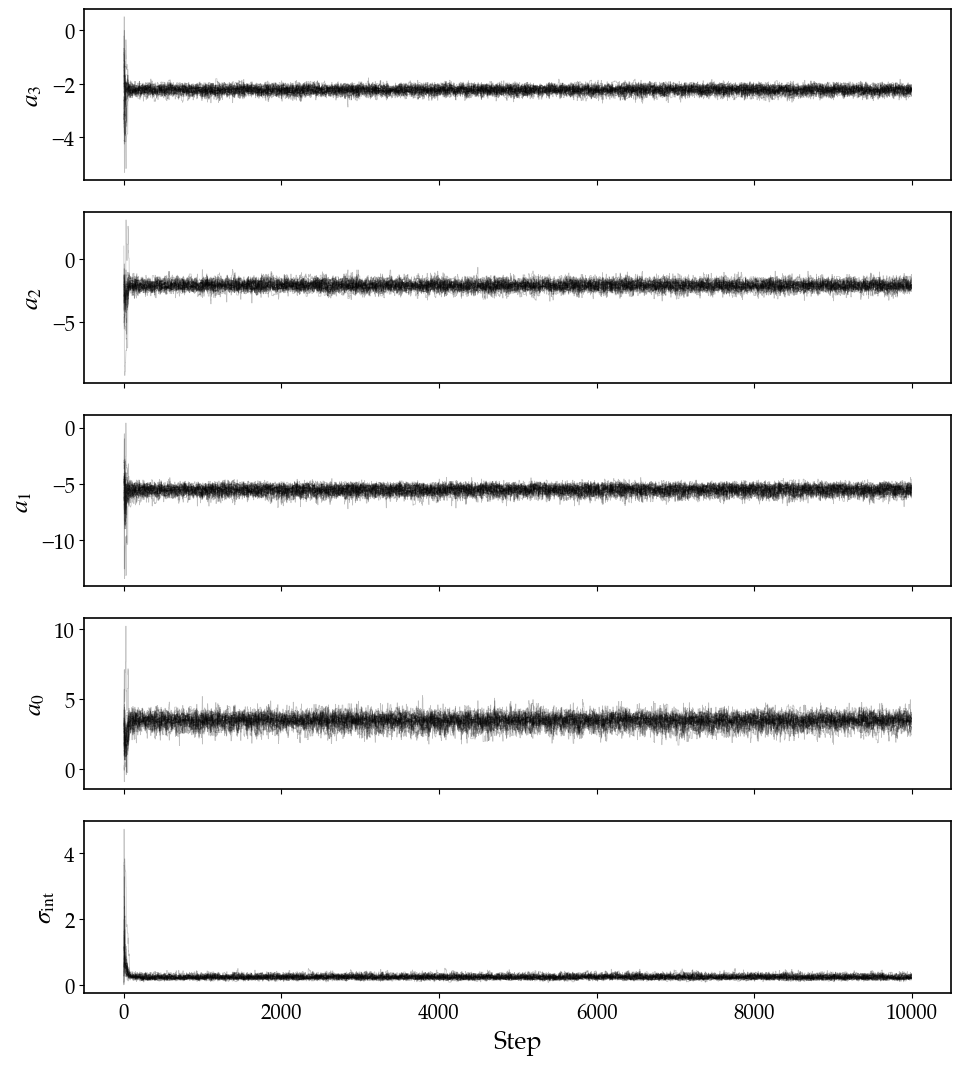

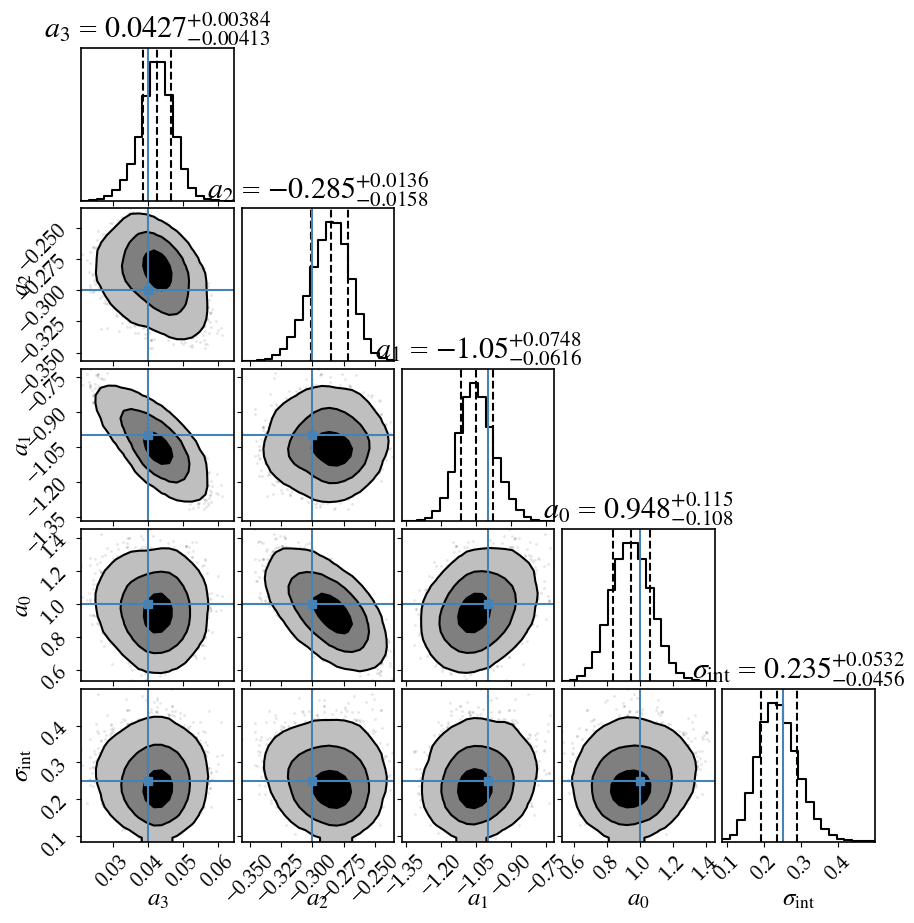

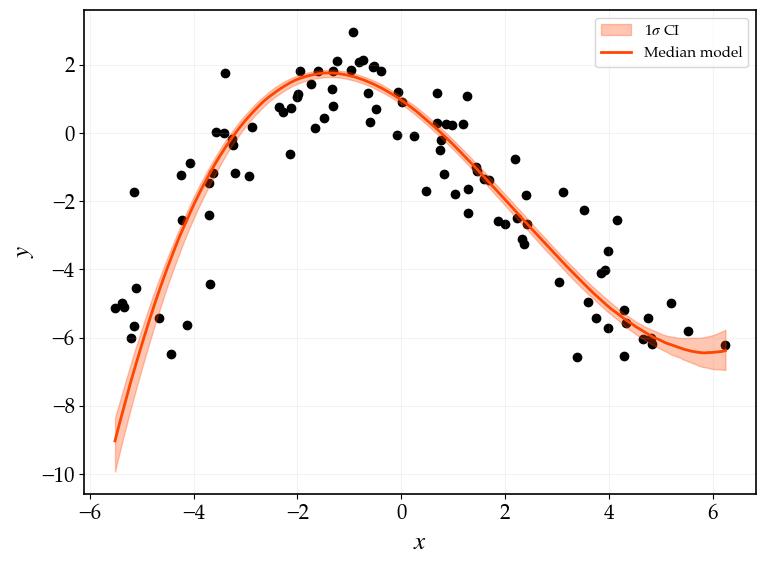

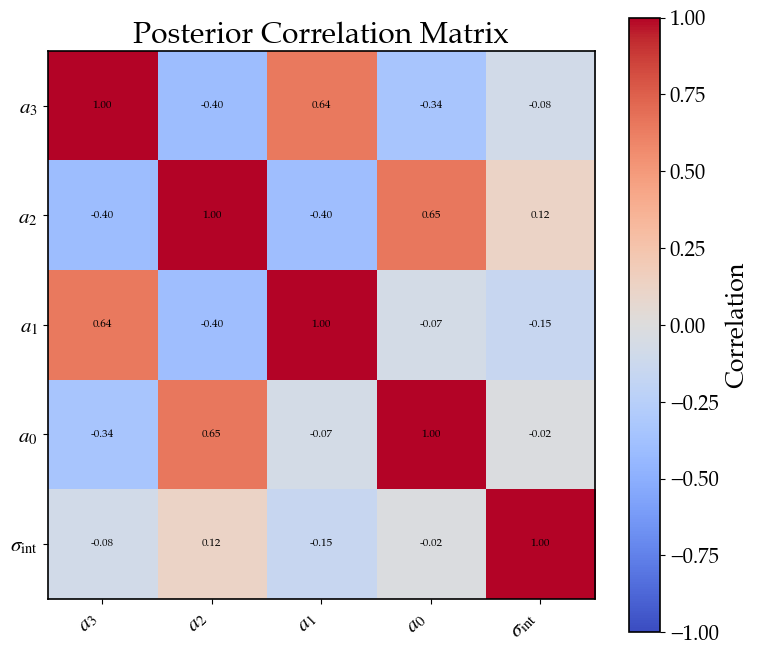


Posterior Polynomial Coefficients
--------------------------------
$a_{3}$              = 4.271457e-02 (+3.841218e-03, -4.134212e-03)
$a_{2}$              = -2.850655e-01 (+1.363614e-02, -1.584646e-02)
$a_{1}$              = -1.051738e+00 (+7.481882e-02, -6.160413e-02)
$a_{0}$              = 9.484265e-01 (+1.145628e-01, -1.082716e-01)
$\sigma_{\rm int}$   = 2.353661e-01 (+5.316298e-02, -4.556606e-02)

Polynomial Equation
-------------------
y = 4.271457e-02x^3 + -2.850655e-01x^2 + -1.051738e+00x + 9.484265e-01

Intrinsic Scatter
-----------------
sigma_int = 2.353661e-01 (+5.316298e-02, -4.556606e-02)

Posterior Covariance Matrix
---------------------------
[[ 1.93851541e-05 -2.52425360e-05 -2.55464421e-04 -2.23058259e-05
  -4.08463349e-06]
 [-2.52425360e-05  2.21439947e-04 -3.69534514e-05 -1.09412330e-03
  -1.01384951e-04]
 [-2.55464421e-04 -3.69534514e-05  5.10065588e-03  2.34411426e-03
   4.56820640e-04]
 [-2.23058259e-05 -1.09412330e-03  2.34411426e-03  1.26560291e-02
   6.0725735

([array([ 0.03858036, -0.30091196, -1.11334254,  0.84015492,  0.18980003]),
  array([ 0.04271457, -0.2850655 , -1.05173842,  0.94842647,  0.23536609]),
  array([ 0.04655579, -0.27142936, -0.97691959,  1.06298931,  0.28852908])],
 array([[ 1.93851541e-05, -2.52425360e-05, -2.55464421e-04,
         -2.23058259e-05, -4.08463349e-06],
        [-2.52425360e-05,  2.21439947e-04, -3.69534514e-05,
         -1.09412330e-03, -1.01384951e-04],
        [-2.55464421e-04, -3.69534514e-05,  5.10065588e-03,
          2.34411426e-03,  4.56820640e-04],
        [-2.23058259e-05, -1.09412330e-03,  2.34411426e-03,
          1.26560291e-02,  6.07257359e-04],
        [-4.08463349e-06, -1.01384951e-04,  4.56820640e-04,
          6.07257359e-04,  2.54055457e-03]]))

In [9]:
analyze_hoggfit(sampler, x_obs, y_obs, order=order, burnin = 2500, truths=[a_true, b_true, c_true, d_true, V_true])
# 

## 最终的